In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np

# Fix path so Python can find your new src/model_trainer.py
if '..' not in sys.path:
    sys.path.append('..')

from src.model_trainer import ModelTrainer

trainer     = ModelTrainer('../data/processed/features_dataset.parquet')
results_df  = trainer.cross_validate_all()

print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

Dataset loaded: 2333 windows, 23 features, 4 classes

Running 5-fold cross-validation...
Model                  |   Acc Mean |  Acc Std |    F1 Mean |   F1 Std
──────────────────────────────────────────────────────────────────────
  Random Forest        |    0.9987  |  0.0017  |    0.9987  |  0.0018
  Gradient Boosting    |    0.9940  |  0.0034  |    0.9933  |  0.0040
  SVM (RBF)            |    0.9996  |  0.0009  |    0.9996  |  0.0009
  KNN                  |    0.9979  |  0.0014  |    0.9978  |  0.0014
  Decision Tree        |    0.9919  |  0.0032  |    0.9900  |  0.0041

CROSS-VALIDATION RESULTS SUMMARY
            Model  Acc_Mean  Acc_Std  F1_Mean  F1_Std  Acc_Min  Acc_Max
        SVM (RBF)    0.9996   0.0009   0.9996  0.0009   0.9979   1.0000
    Random Forest    0.9987   0.0017   0.9987  0.0018   0.9957   1.0000
              KNN    0.9979   0.0014   0.9978  0.0014   0.9957   1.0000
Gradient Boosting    0.9940   0.0034   0.9933  0.0040   0.9893   0.9979
    Decision Tree    0.99

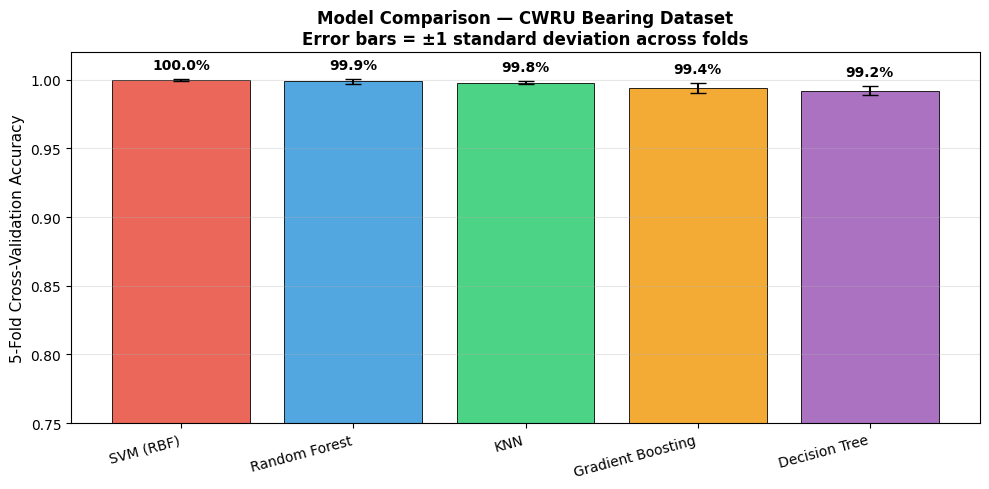

In [2]:
models   = results_df['Model'].tolist()
acc_mean = results_df['Acc_Mean'].tolist()
acc_std  = results_df['Acc_Std'].tolist()

COLORS_BAR = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    models, acc_mean,
    yerr       = acc_std,
    color      = COLORS_BAR,
    alpha      = 0.85,
    capsize    = 6,
    edgecolor  = 'black',
    linewidth  = 0.7,
    error_kw   = {'linewidth': 1.5}
)

# Label each bar with accuracy
for bar, val, std in zip(bars, acc_mean, acc_std):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + std + 0.005,
        f'{val:.1%}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_ylim(0.75, 1.02)
ax.set_ylabel('5-Fold Cross-Validation Accuracy', fontsize=11)
ax.set_title(
    'Model Comparison — CWRU Bearing Dataset\n'
    'Error bars = ±1 standard deviation across folds',
    fontsize=12, fontweight='bold'
)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/day7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()